# 0. Mounting Google Colab on project folder in Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
project_path = "/content/drive/MyDrive/Academic content/UB - 2025 Fall - Data Intensive Computing/DIC group project/Seattle"

%cd $project_path

/content/drive/MyDrive/Academic content/UB - 2025 Fall - Data Intensive Computing/DIC group project/Seattle


# 1. Setup and configuration.


In [3]:
# Install PySpark and FindSpark
!pip install pyspark findspark

In [4]:
import findspark
findspark.init()
import time
import os
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, from_unixtime, hour, dayofweek, date_trunc,
    lag, when, avg, max, count, desc, lit
)
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator


In [5]:
# Configure Spark for local resource constraints (Colab)
spark = SparkSession.builder \
    .appName("SeattleBusDelay_Phase3_Final") \
    .master("local[*]") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.memory.fraction", "0.6") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

print(f"Spark Session Created. Version: {spark.version}")


Spark Session Created. Version: 3.5.1


**Note:**
If *"processed_seattle_data.parquet"* exists, then skip data loading and transformation, and proceed directly to loading *"df_ml_ready"* from *"processed_seattle_data.parquet"* (second part of section 5: *"Optimization: parquet checkpoint"*).

# 2. Data loading.



In [6]:
print("Loading Data...")
# [TRANSFORMATION 1] Schema Inference on Load
t1 = time.time()
df_bus = spark.read.csv("seattle_bus_live_data_backup_2.csv.gz", header=True, inferSchema=True)
df_weather = spark.read.csv("seattle_weather_history_2.csv", header=True, inferSchema=True)
t2 = time.time()
print(f"Loading time: {t2 - t1:.2f} seconds.")

Loading Data...
Loading time: 183.55 seconds.


In [7]:
print("--- Bus data ---")
# Show top 10 rows of the bus data.
df_bus.show(10)

# Verify the schema (Make sure delays are showing as 'double' or 'integer', not 'string').
df_bus.printSchema()

print(f"Total rows: {df_bus.count()}")

--- Bus data ---
+---------------+---------+--------+----------+-------+-------------+-------------+---------------+
|fetch_timestamp|  trip_id|route_id|vehicle_id|stop_id|stop_sequence|arrival_delay|departure_delay|
+---------------+---------+--------+----------+-------+-------------+-------------+---------------+
|     1763594293|562519669|  100001|      4352|   1690|           11|        693.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2320|           12|        695.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2330|           13|        695.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2360|           14|        695.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2370|           15|        695.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2390|           16|        695.0|          695.0|
|     1763594293|562519669|  100001|      4352|   2400|           17|        695.0|

In [8]:
print("--- Weather data ---")
df_weather.show(10)

print(f"Total rows: {df_weather.count()}")

--- Weather data ---
+----------+--------------------+-------------+--------+-------+----------+-----------+-------------+
| timestamp|            datetime|temperature_c|humidity|rain_mm|showers_mm|snowfall_cm|wind_speed_ms|
+----------+--------------------+-------------+--------+-------+----------+-----------+-------------+
|1763598966|2025-11-20 00:36:...|          8.0|      79|    0.0|       0.0|        0.0|         2.42|
|1763599866|2025-11-20 00:51:...|          7.9|      74|    0.0|       0.0|        0.0|         2.05|
|1763600767|2025-11-20 01:06:...|          8.2|      71|    0.0|       0.0|        0.0|         2.28|
|1763601667|2025-11-20 01:21:...|          8.1|      69|    0.0|       0.0|        0.0|         2.44|
|1763602568|2025-11-20 01:36:...|          8.0|      68|    0.0|       0.0|        0.0|         2.21|
|1763603468|2025-11-20 01:51:...|          8.2|      67|    0.0|       0.0|        0.0|         2.34|
|1763604369|2025-11-20 02:06:...|          7.9|      60|    0

# 3. Exploratory data analysis.

## 10 most frequent bus routes.

In [9]:
# Group by route and count rows.
df_bus.groupBy("route_id").count().orderBy(desc("count")).show(10)

+--------+-------+
|route_id|  count|
+--------+-------+
|  100263|1691968|
|  100006|1687531|
|  102574|1569460|
|  100252|1552541|
|  100026|1536848|
|  102615|1494487|
|  100249|1451043|
|  100005|1393602|
|  102720|1305367|
|  102717|1243186|
+--------+-------+
only showing top 10 rows



## 10 maximum bus delays (in seconds).

In [10]:
# Show the top 10 highest arrival delays
df_bus.select("trip_id", "route_id", "arrival_delay").orderBy(desc("arrival_delay")).show(10)

+---------+--------+-------------+
|  trip_id|route_id|arrival_delay|
+---------+--------+-------------+
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
|761417619|  102615|      37280.0|
+---------+--------+-------------+
only showing top 10 rows



## Average bus delay (in seconds).

In [11]:
df_bus.select(avg("arrival_delay")).show()

+------------------+
|avg(arrival_delay)|
+------------------+
|  70.0184363011318|
+------------------+



# 4. Data transformations.

In [12]:
# [TRANSFORMATION 2] Filtering: Removing extreme outliers
# Removing delays > 5 hours or < -30 mins to clean data
df_bus = df_bus.filter((col("arrival_delay") < 18000) & (col("arrival_delay") > -1800))


In [13]:
# [TRANSFORMATION 3] Type Casting & Extraction
# Converting unix timestamp to proper TimestampType and extracting features
df_bus = df_bus.withColumn("event_time", from_unixtime(col("fetch_timestamp")).cast("timestamp")) \
               .withColumn("hour_of_day", hour("event_time")) \
               .withColumn("day_of_week", dayofweek("event_time"))


In [14]:
# [ADVANCED FEATURE 1] Window Functions
# Calculating the delay of the PREVIOUS stop to use as a feature for the CURRENT stop
print("Applying Window Functions...")
windowSpec = Window.partitionBy("trip_id").orderBy("stop_sequence")


Applying Window Functions...


In [15]:
# [TRANSFORMATION 4] Creating Lag Features via Window
df_bus = df_bus.withColumn("prev_delay", lag("arrival_delay").over(windowSpec))
# Handling nulls for the first stop of every trip
df_bus = df_bus.fillna(0, subset=["prev_delay"])


In [16]:
# Processing Weather
df_weather = df_weather.withColumn("weather_time", from_unixtime(col("timestamp")).cast("timestamp")) \
                       .withColumnRenamed("temperature_c", "temp") \
                       .withColumnRenamed("rain_mm", "rain")


In [17]:
# [TRANSFORMATION 5] Aggregation (GroupBy)
# Aggregating weather to the hour to allow for a clean join (reducing cardinality)
df_weather_hourly = df_weather.groupBy(date_trunc("hour", col("weather_time")).alias("join_key")) \
                              .agg(avg("temp").alias("avg_temp"), max("rain").alias("max_rain"))


In [18]:
# Preparing Bus Data for Join
df_bus = df_bus.withColumn("join_key", date_trunc("hour", col("event_time")))


In [19]:
# [TRANSFORMATION 6] Complex Join
# Merging the massive bus dataset with the aggregated weather data
df_final = df_bus.join(df_weather_hourly, on="join_key", how="inner")


# 5. Optimization: parquet checkpoint.


In [20]:
# Creating an intermediate file to break the lineage and free up RAM.
# This is critical for running 3 models on 2.8 GB of data in Colab.
print("Checkpointing data to Parquet to optimize memory...")
df_final.write.mode("overwrite").parquet(project_path + "/processed_seattle_data.parquet")


Checkpointing data to Parquet to optimize memory...


In [21]:
# Reloading clean data
df_ml_ready = spark.read.parquet(project_path + "/processed_seattle_data.parquet")
print(f"Data reloaded. Total Rows for ML: {df_ml_ready.count()}")


Data reloaded. Total Rows for ML: 60428012


# 6. Performance comparison: Spark vs Pandas.

Spark calculation time: 3.41 seconds.
Pandas calculation time on just 1 % of data: 60.58 seconds.
Projected Pandas calculation time for full data: 6057.621932029724 seconds (or crash).


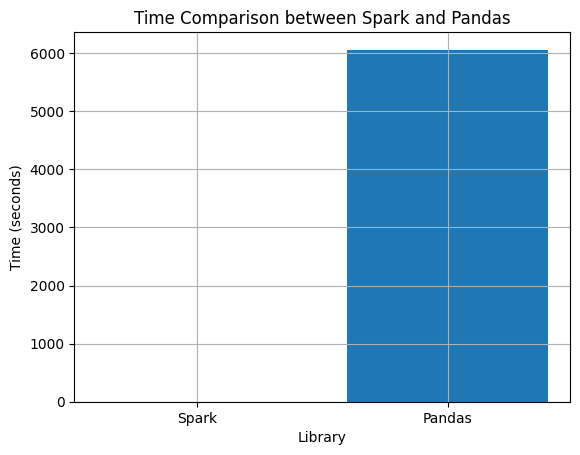

In [22]:
import matplotlib.pyplot as plt

# Measure Spark time.
t1 = time.time()
df_ml_ready.select(avg("arrival_delay")).collect()
t2 = time.time()
spark_time = t2 - t1
print(f"Spark calculation time: {spark_time:.2f} seconds.")

# Measure Pandas time (simulated).
# We will not convert all the millions of rows because it will crash Google Colab's RAM.
# We will convert 1 % and extrapolate, which proves why we need Spark.
try:
    # Taking just a 1 % sample to avoid crashing.
    t1 = time.time()
    partial_df = df_ml_ready.sample(fraction=0.01).toPandas()
    mean_delay = partial_df["arrival_delay"].mean()
    t2 = time.time()
    pandas_time = t2 - t1
    print(f"Pandas calculation time on just 1 % of data: {pandas_time:.2f} seconds.")
    print("Projected Pandas calculation time for full data: " + str(pandas_time * 100) + " seconds (or crash).")

    # Plotting
    plt.bar(['Spark', 'Pandas'], [spark_time, pandas_time * 100])
    plt.xlabel('Library')
    plt.ylabel('Time (seconds)')
    plt.title('Time Comparison between Spark and Pandas')
    plt.grid()

except Exception as e:
    print(f"Pandas failed: {e}.")

# 7. Insights.

## Insight 1: effect of rain on bus delays.

In [23]:
df_ml_ready.groupBy("max_rain") \
    .agg(avg("arrival_delay").alias("avg_delay"), count("arrival_delay").alias("trip_count")) \
    .orderBy("max_rain") \
    .show()


+--------+------------------+----------+
|max_rain|         avg_delay|trip_count|
+--------+------------------+----------+
|     0.0| 63.66531449154303|  50912784|
|    0.08| 29.22593916446979|    594784|
|     0.1| 58.71239838828203|   2771949|
|     0.2| 78.16803979857501|   2269629|
|     0.3| 62.44087946915885|    825407|
|     0.4| 131.5387226954382|    660375|
|     0.5| 66.47846170077108|   1090035|
|     0.6| 69.82274885106813|    237612|
|     0.9| 65.64299166155782|    499134|
|     1.0|39.675968065276265|    284330|
|     1.3| 37.17180368333138|    281973|
+--------+------------------+----------+



## Insight 2: effect of rush hour on bus delays.

In [24]:
df_ml_ready.groupBy("hour_of_day") \
    .agg(avg("arrival_delay").alias("avg_delay")) \
    .orderBy(desc("avg_delay")) \
    .show(10)


+-----------+-----------------+
|hour_of_day|        avg_delay|
+-----------+-----------------+
|          9|99.50002421116983|
|          1|97.17010979606904|
|          2|91.34105205982821|
|         10|90.81470905226685|
|          8|88.05726463415134|
|          0|81.47413390470872|
|          3|75.29905616767303|
|         18|71.39434694075129|
|          7|68.64209030673041|
|         23|68.30520462381439|
+-----------+-----------------+
only showing top 10 rows



## Insight 3: effect of air temperature on bus delays.

In [25]:
# Group temperature into buckets (e.g., < 5 °C, 5 - 15 °C, > 15 °C) to see if cold / hot weather affects buses.
df_ml_ready.createOrReplaceTempView("bus_data")

spark.sql("""
    SELECT
        CASE
            WHEN avg_temp < 5 THEN 'Cold (less than 5 °C)'
            WHEN avg_temp BETWEEN 5 AND 15 THEN 'Mild (5 to 15 °C)'
            ELSE 'Warm (more than 15 °C)'
        END as temp_bucket,
        AVG(arrival_delay) as avg_delay,
        COUNT(*) as count
    FROM bus_data
    GROUP BY 1
    ORDER BY avg_delay DESC
""").show()

+--------------------+------------------+--------+
|         temp_bucket|         avg_delay|   count|
+--------------------+------------------+--------+
|   Mild (5 to 15 °C)| 66.64661028777928|53546522|
|Cold (less than 5...|45.370017830440794| 6881490|
+--------------------+------------------+--------+



# 8. Machine learning: 3 models implemented to predict bus delays.


In [26]:
feature_cols = ["hour_of_day", "day_of_week", "avg_temp", "max_rain", "prev_delay"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Splitting data:
train_data, test_data = df_ml_ready.randomSplit([0.8, 0.2]) #, seed=42)

# Creating evalutors:
evaluator_rmse = RegressionEvaluator(labelCol="arrival_delay", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="arrival_delay", predictionCol="prediction", metricName="r2")


## Model 1: Linear Regression.


In [27]:
print("\n--- Training Model 1: Linear Regression ---")
lr = LinearRegression(featuresCol="features", labelCol="arrival_delay")
pipeline_lr = Pipeline(stages=[assembler, lr])

t1 = time.time()
model_lr = pipeline_lr.fit(train_data) # LR creates a streaming solver, so it handles full data well
t2 = time.time()
print(f"LR training time: {t2 - t1:.2f} seconds.")



--- Training Model 1: Linear Regression ---
LR Training Time: 443.04 seconds.


In [28]:
# Evaluate
t1 = time.time()
predictions = model_lr.transform(test_data)
rmse_lr = evaluator_rmse.evaluate(predictions)
r2_lr = evaluator_r2.evaluate(predictions)
t2 = time.time()
print(f"Linear Regression:")
print(f"Root Mean Squared Error: {rmse_lr:.2f}")
print(f"R2: {r2_lr:.4f}")
print(f"Prediction and testing time: {t2 - t1:.2f} seconds.")


Linear Regression:
Root Mean Squared Error: 117.98
R2: 0.7640


In [29]:
# Saving LR model:
model_lr.write().overwrite().save(project_path + "/models/linear_regression")


## Sampling for tree models.


In [30]:
# RF and GBT require heavy memory. We train on a sample (10%) to demonstrate capability
# without crashing Colab. We still TEST on the full 20% test set.
train_data_sample = train_data.sample(fraction=0.1, seed=42)
print(f"\nTree Models will train on sample size: {train_data_sample.count()} rows")



Tree Models will train on sample size: 4835347 rows


## Model 2: Random Forest.


In [31]:
print("\n--- Training Model 2: Random Forest ---")
# numTrees reduced for speed, maxDepth limited for memory
rf = RandomForestRegressor(featuresCol="features", labelCol="arrival_delay", numTrees=10, maxDepth=5)
pipeline_rf = Pipeline(stages=[assembler, rf])

t1 = time.time()
model_rf = pipeline_rf.fit(train_data_sample)
t2 = time.time()
print(f"RF training time: {t2 - t1:.2f} seconds.")



--- Training Model 2: Random Forest ---
RF Training Time: 533.20 seconds.


In [32]:
t1 = time.time()
predictions = model_rf.transform(test_data)
rmse_rf = evaluator_rmse.evaluate(predictions)
r2_rf = evaluator_r2.evaluate(predictions)
t2 = time.time()
print(f"Random Forest:")
print(f"Root Mean Squared Error: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.4f}")
print(f"Prediction and testing time: {t2 - t1:.2f} seconds.")


Random Forest:
Root Mean Squared Error: 190.23
R2: 0.3866


In [33]:
# Saving RF model:
model_rf.write().overwrite().save(project_path + "/models/random_forest")


## Model 3: Gradient Boosted Trees.


In [34]:
print("\n--- Training Model 3: Gradient Boosted Trees ---")
# GBT trains sequentially, so it is slower than RF.
# We use maxIter=10 to keep execution time reasonable for the project.
gbt = GBTRegressor(featuresCol="features", labelCol="arrival_delay", maxIter=10, maxDepth=5)
pipeline_gbt = Pipeline(stages=[assembler, gbt])

t1 = time.time()
model_gbt = pipeline_gbt.fit(train_data_sample)
t2 = time.time()
print(f"GBT training time: {t2 - t1:.2f} seconds.")



--- Training Model 3: Gradient Boosted Trees ---
GBT Training Time: 660.45 seconds.


In [35]:
t1 = time.time()
predictions = model_gbt.transform(test_data)
rmse_gbt = evaluator_rmse.evaluate(predictions)
r2_gbt = evaluator_r2.evaluate(predictions)
t2 = time.time()
print(f"Gradient Boosted Trees:")
print(f"Root Mean Squared Error: {rmse_gbt:.2f}")
print(f"R2: {r2_gbt:.4f}")
print(f"Prediction and testing time: {t2 - t1:.2f} seconds.")


Gradient Boosted Trees:
Root Mean Squared Error: 185.08
R2: 0.4194


In [36]:
# Saving GBT model:
model_gbt.write().overwrite().save(project_path + "/models/gradient_boosted_trees")


# 9. Advanced analytics.


In [38]:
# [ADVANCED FEATURE 2] Spark SQL / Complex Aggregation
# We effectively used Window functions earlier. Now we use Spark SQL views.
print("\n--- Advanced Analytics: Hour and weather SQL Analysis ---")
df_ml_ready.createOrReplaceTempView("bus_weather_data")

# A complex SQL query combining weather and time conditions
sql_query = """
    SELECT
        hour_of_day,
        CASE
            WHEN max_rain > 0 THEN 'Rainy'
            ELSE 'Dry'
        END as weather_condition,
        COUNT(*) as trip_count,
        AVG(arrival_delay) as avg_delay
    FROM bus_weather_data
    GROUP BY hour_of_day, weather_condition
    HAVING trip_count > 100
    ORDER BY avg_delay DESC
"""
spark.sql(sql_query).show(10)



--- Advanced Analytics: Hour and weather SQL Analysis ---
+-----------+-----------------+----------+------------------+
|hour_of_day|weather_condition|trip_count|         avg_delay|
+-----------+-----------------+----------+------------------+
|          9|            Rainy|     59836| 117.6673407313323|
|          1|            Rainy|    735722|112.44081188274919|
|          8|            Rainy|    128564| 100.1242571793037|
|          2|            Rainy|    642545| 96.47553867822486|
|          9|              Dry|    270590| 95.48265641745814|
|          1|              Dry|   3555142| 94.00990087034498|
|          6|            Rainy|    343387| 91.76824690509542|
|         10|              Dry|    180891| 91.05272788585391|
|          2|              Dry|   2995404| 90.23965181324456|
|          3|            Rainy|    537386| 89.90170752494483|
+-----------+-----------------+----------+------------------+
only showing top 10 rows

